In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
dataset_base = '/home/alex/flex/BLIP2_DATASET/train'
plots_base = '/home/alex/flex/MCMD_Sim/results'
run_folders = os.listdir(dataset_base)
summary_data = []

In [4]:
for run in run_folders:
    data_path = os.path.join(dataset_base, run, 'data_out.csv')
    df = pd.read_csv(data_path)
    vx, vy, vz, yr = df.iloc[:, :4].values.T
    row_data = {
        'run': run,
        'vx_mean': vx.mean(),
        'vy_mean': vy.mean(),
        'vz_mean': vz.mean(),
        'yr_mean': yr.mean(),
        'vx_std': vx.std(),
        'vy_std': vy.std(),
        'vz_std': vz.std(),
        'yr_std': yr.std(),
        'total_length': len(df)
    }
    summary_data.append(row_data)

summary_df = pd.DataFrame(summary_data)
    

In [5]:
summary_df[['run', 'total_length']].sort_values('total_length', ascending=False).iloc[-15:]

,run,total_length
431,2025_03_19_01_47_43_left,51
424,2025_03_19_02_12_31_left,50
227,2025_03_19_01_41_01_right,50
254,2025_03_19_02_13_55_left,50
414,2025_03_19_01_53_09_left,49
175,2025_03_19_01_50_04_left,49
442,2025_03_19_01_51_48_left,49
449,2025_03_19_01_57_05_left,48
465,2025_03_19_02_08_39_right,48
177,2025_03_19_02_17_33_left,45


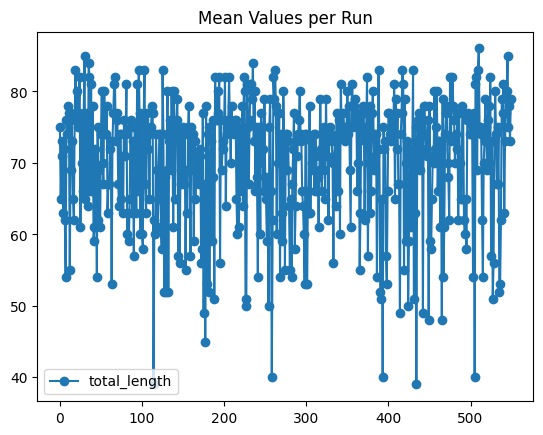

In [6]:
summary_df[['total_length']].plot(kind='line', marker='o')
plt.title("Mean Values per Run")
plt.show()

In [7]:
bad_data_by_sim_xy = {}

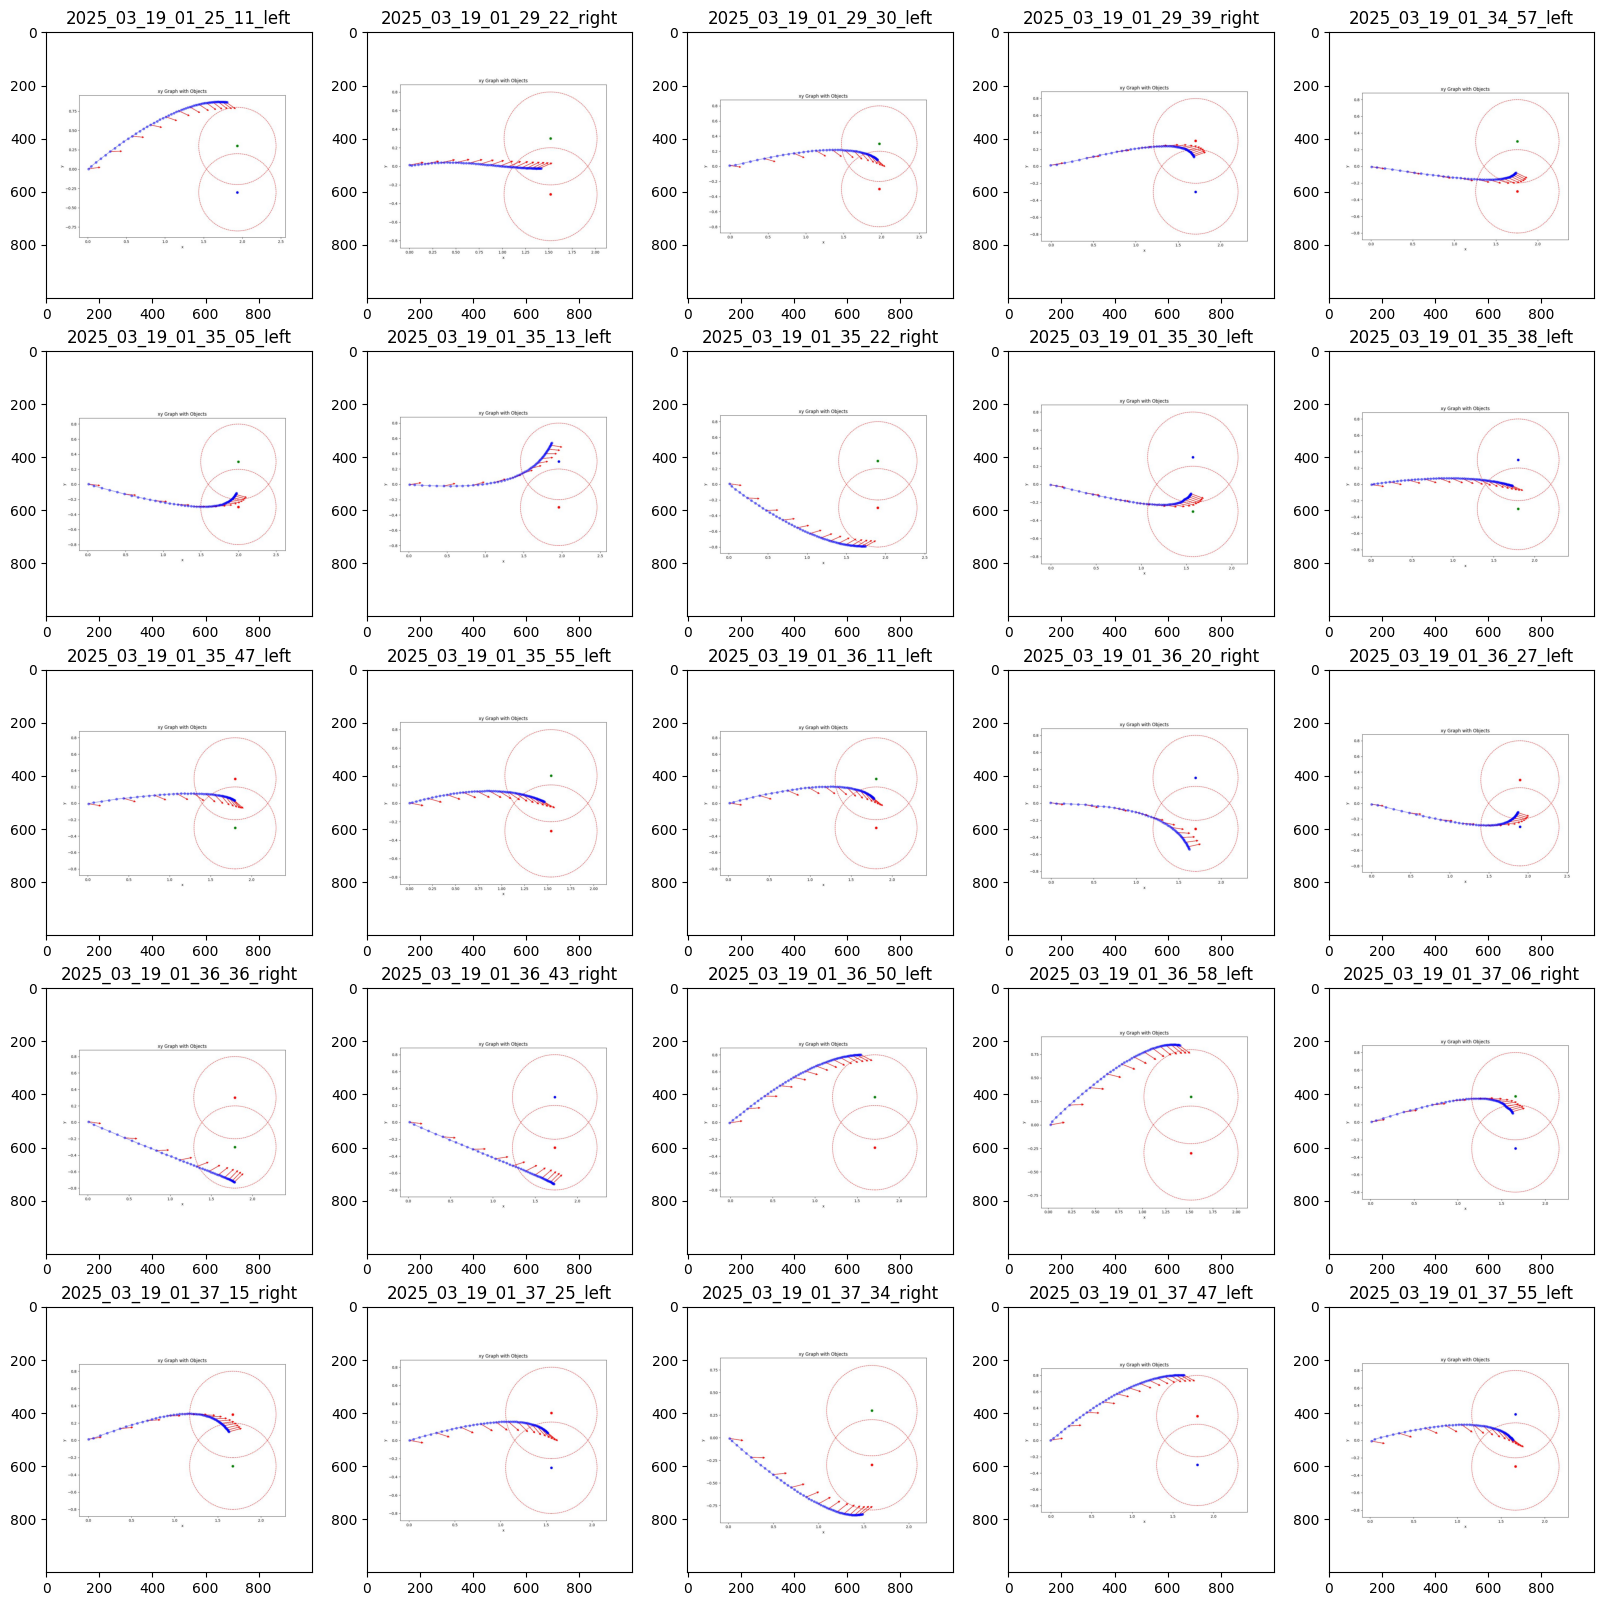

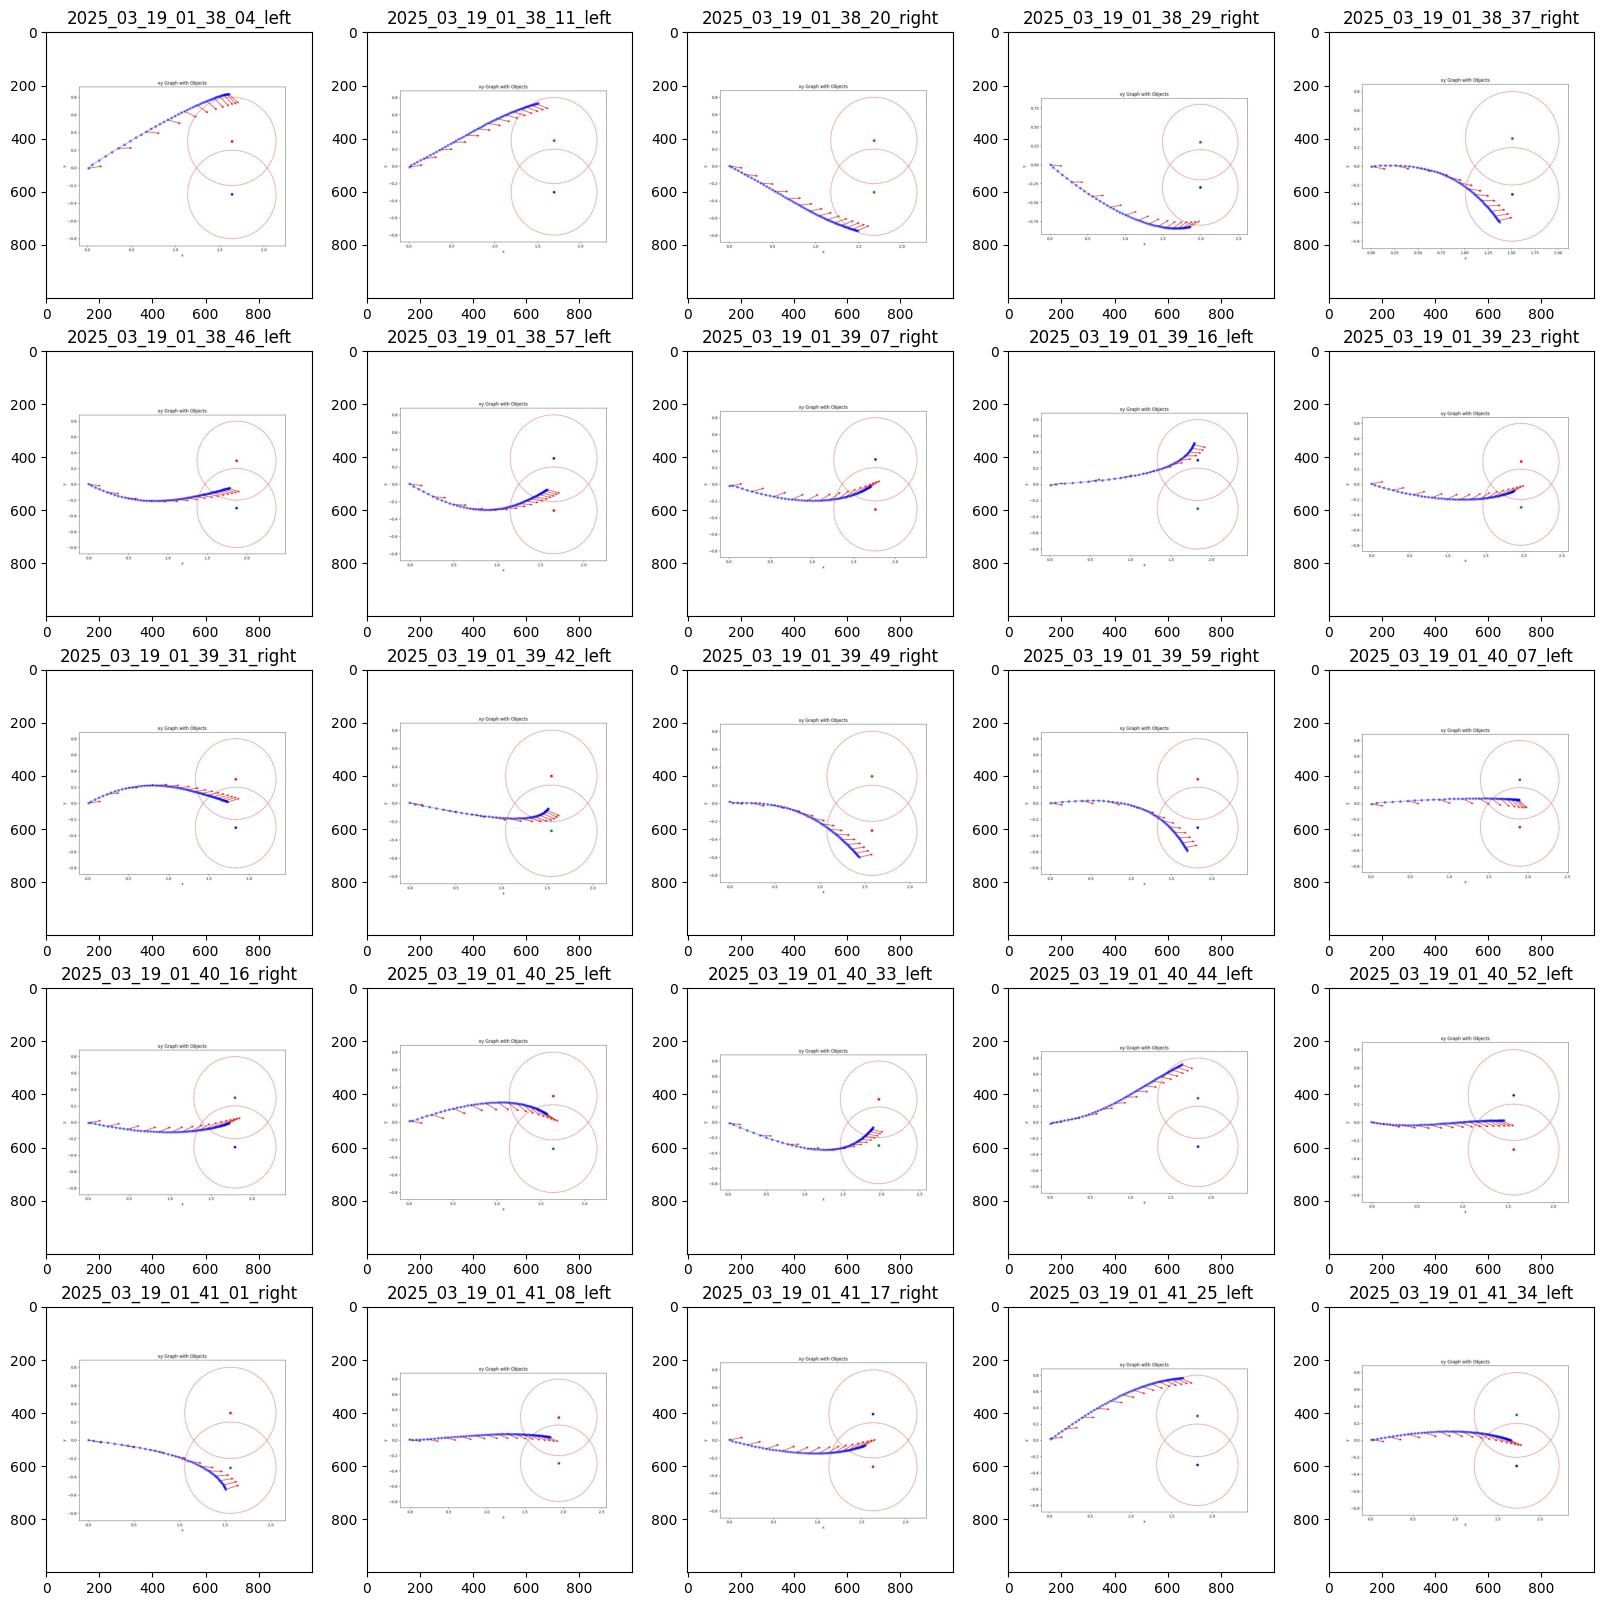

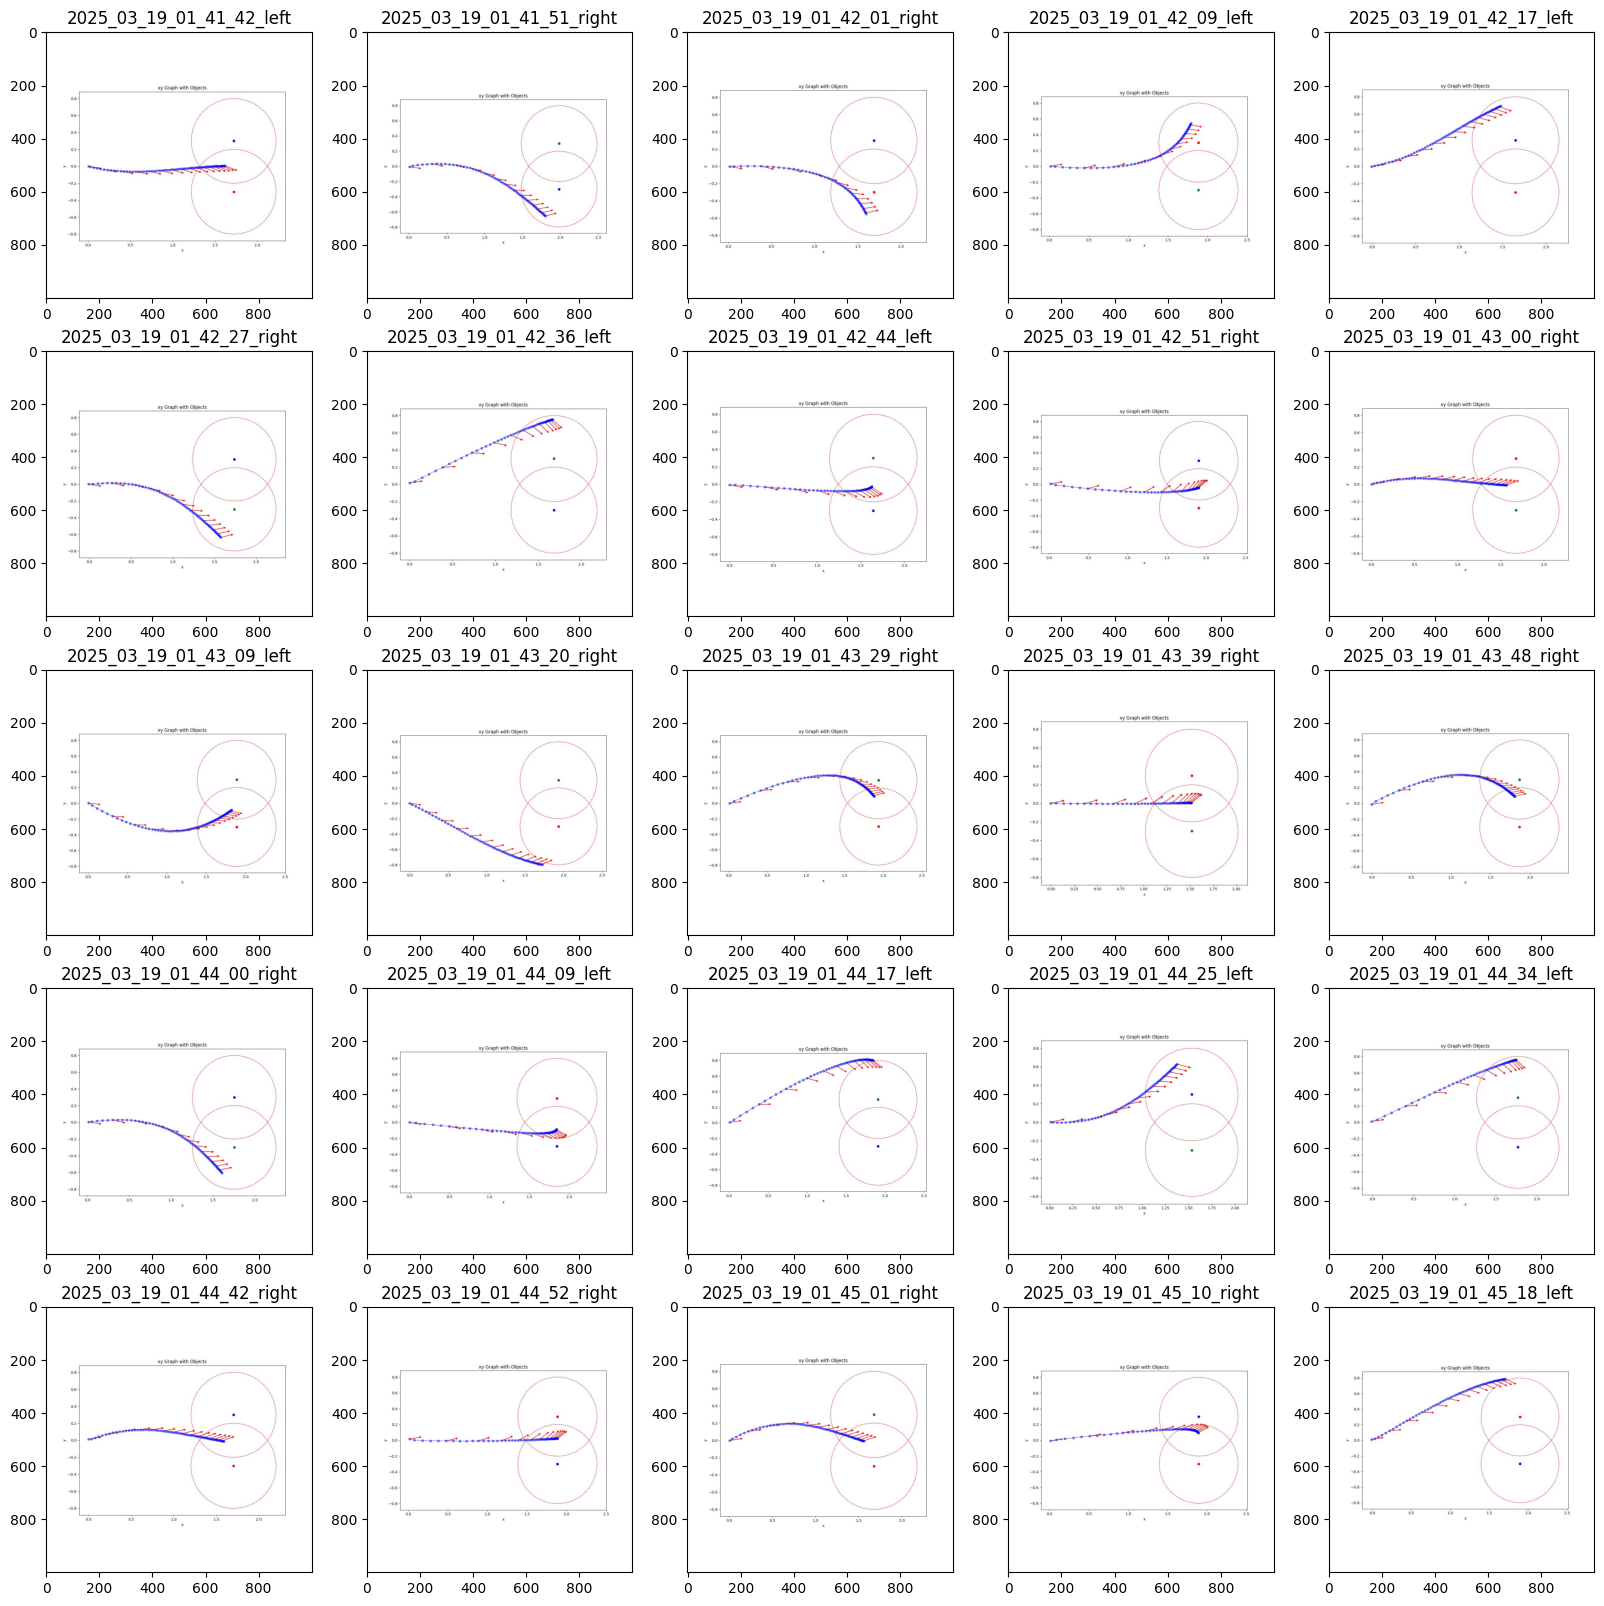

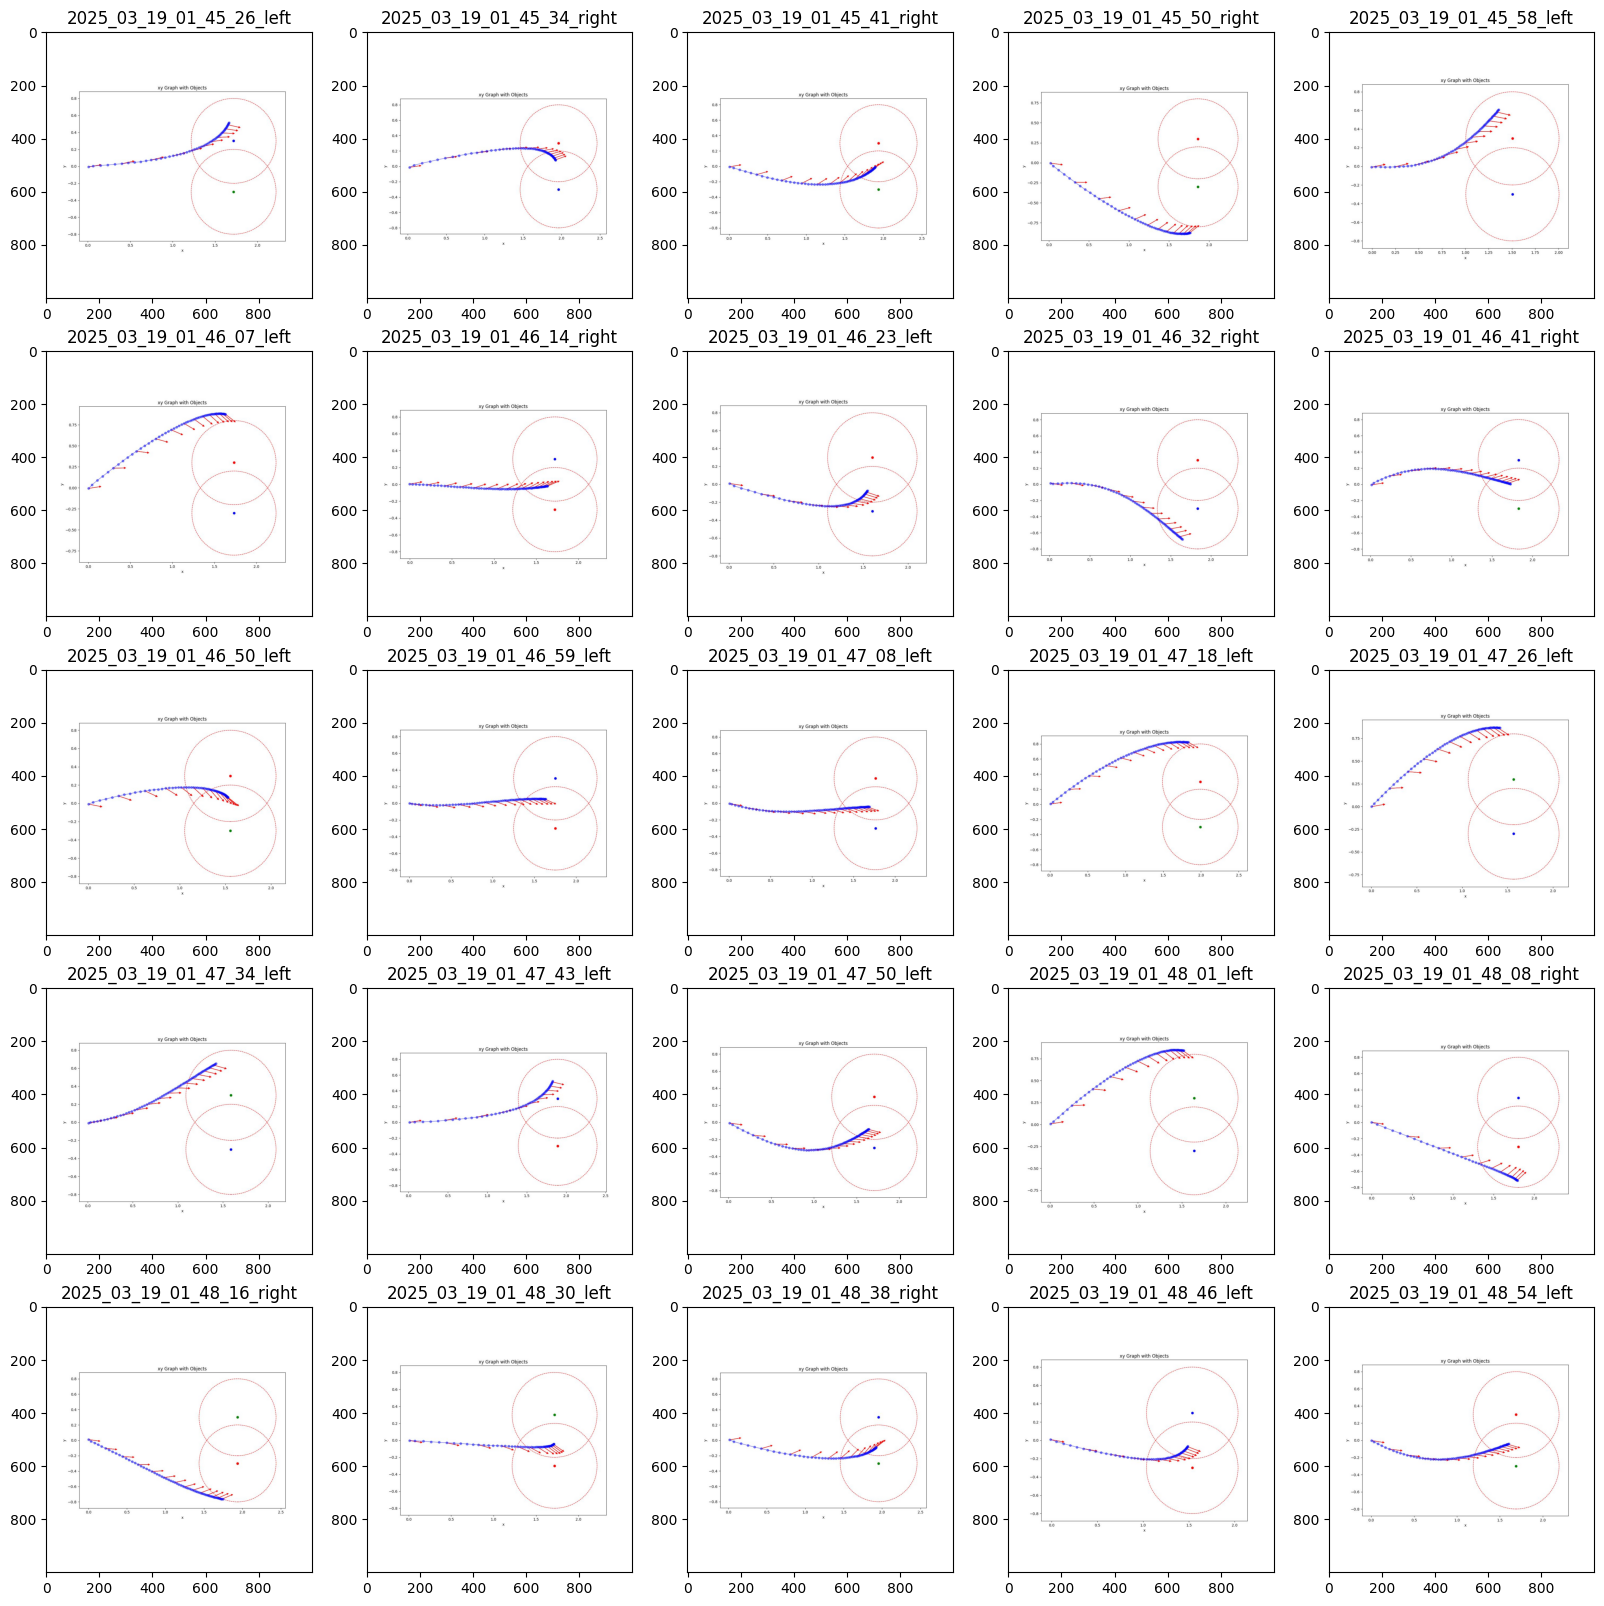

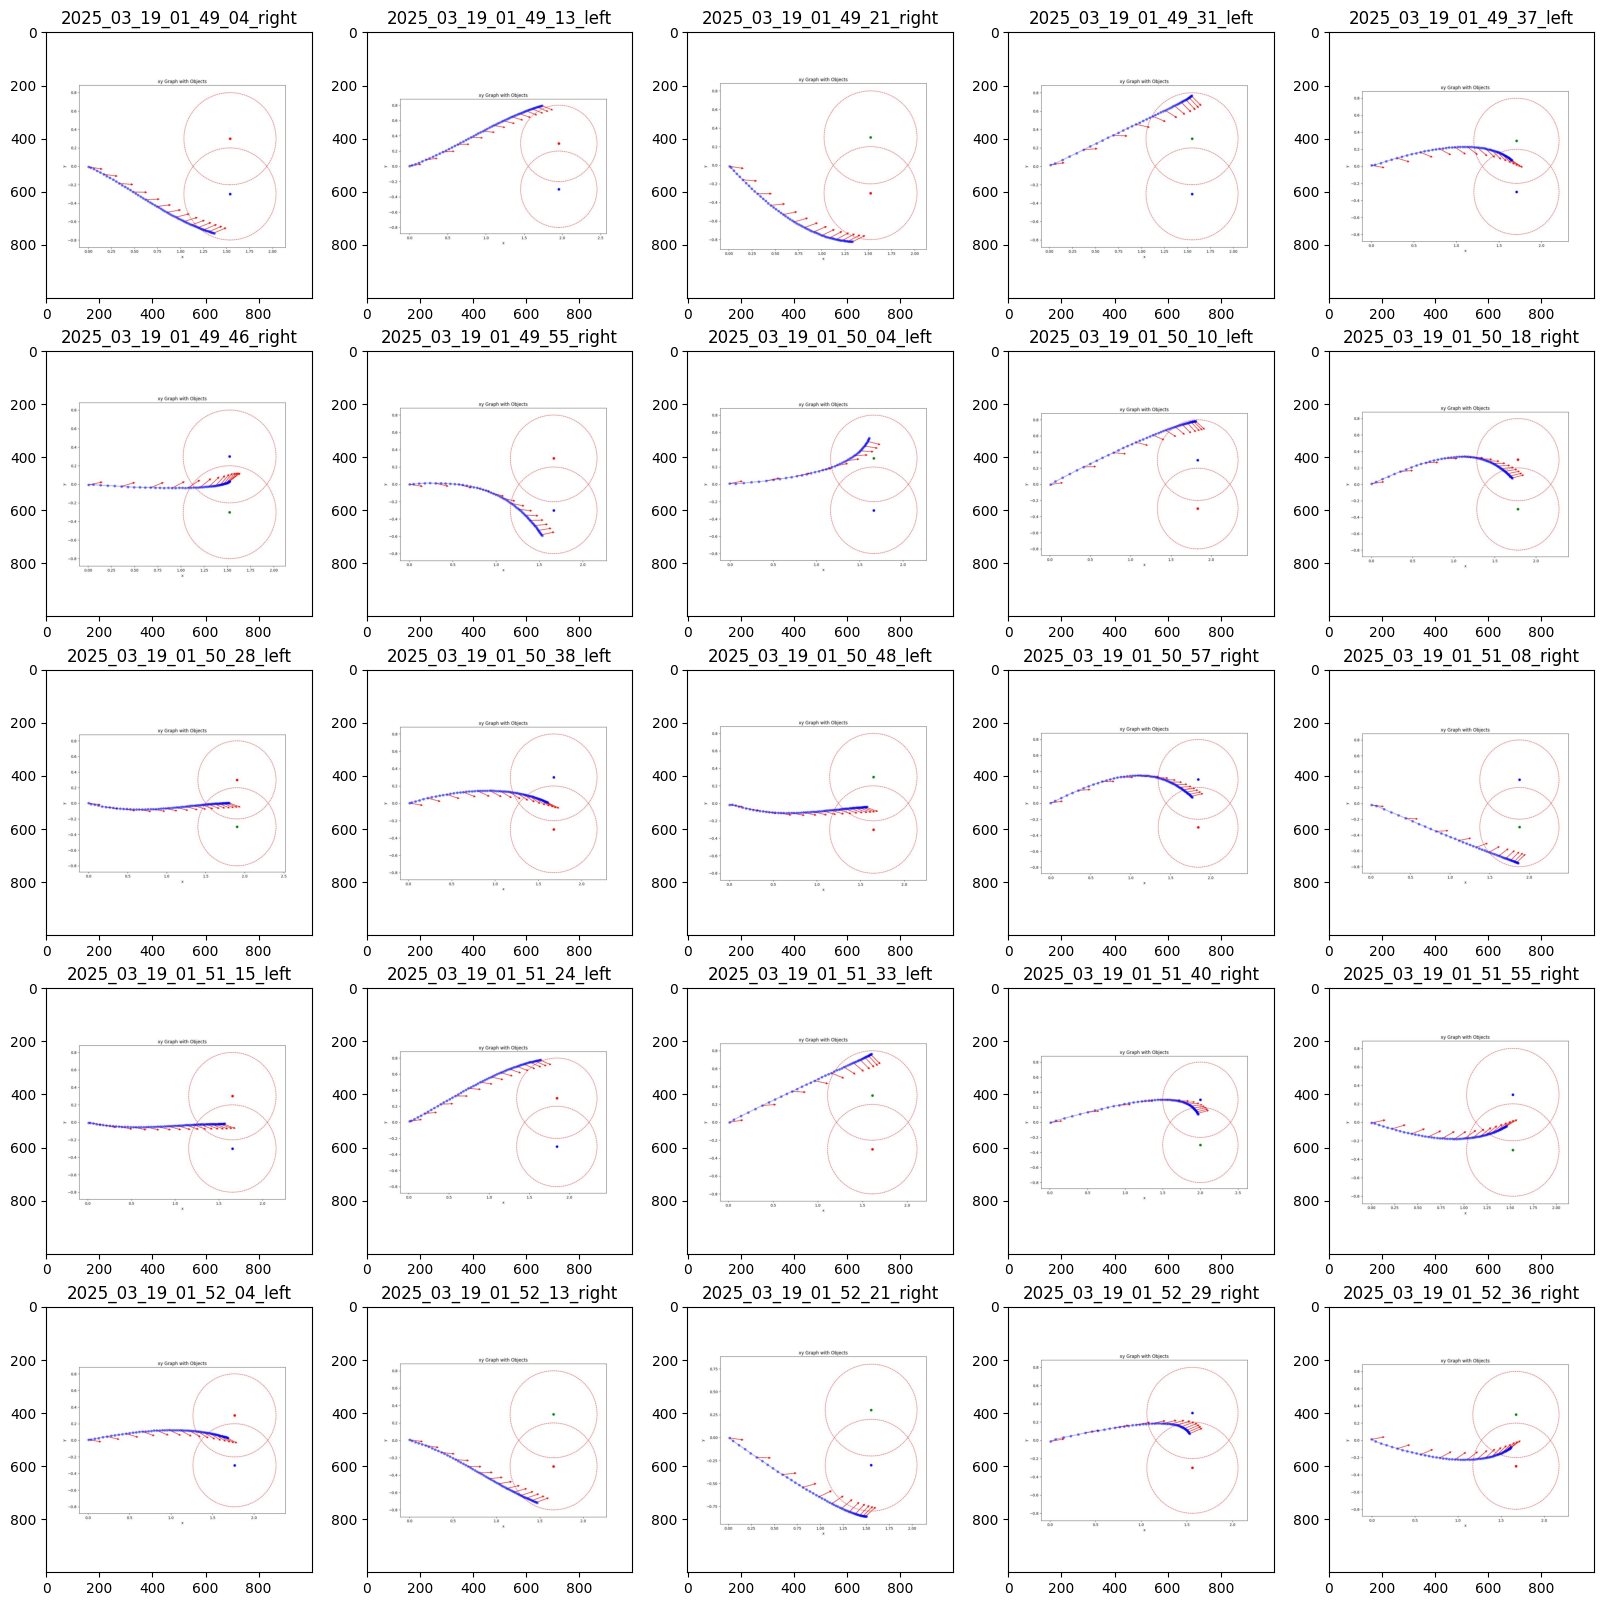

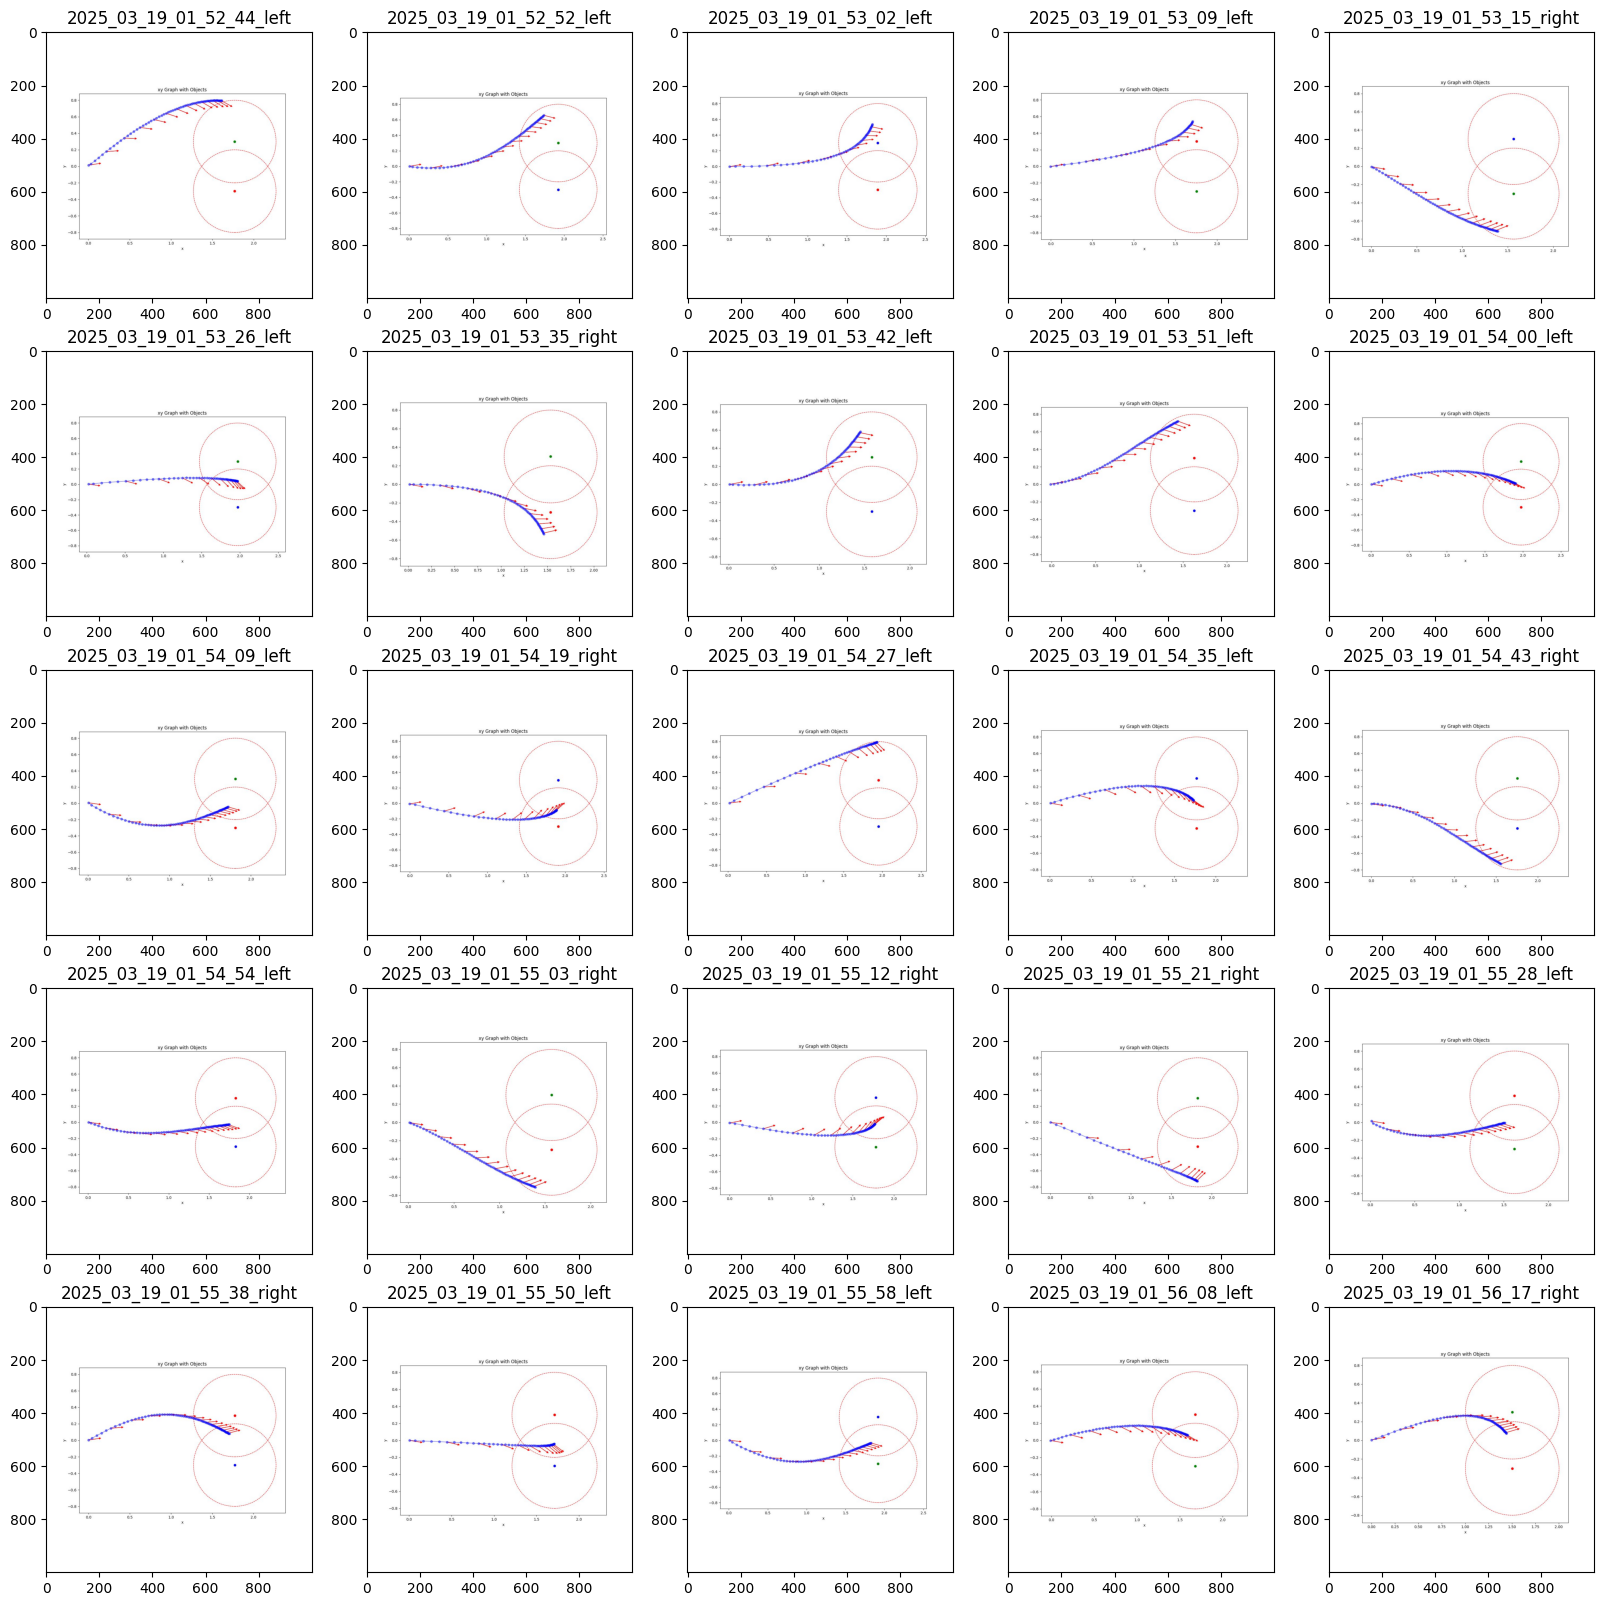

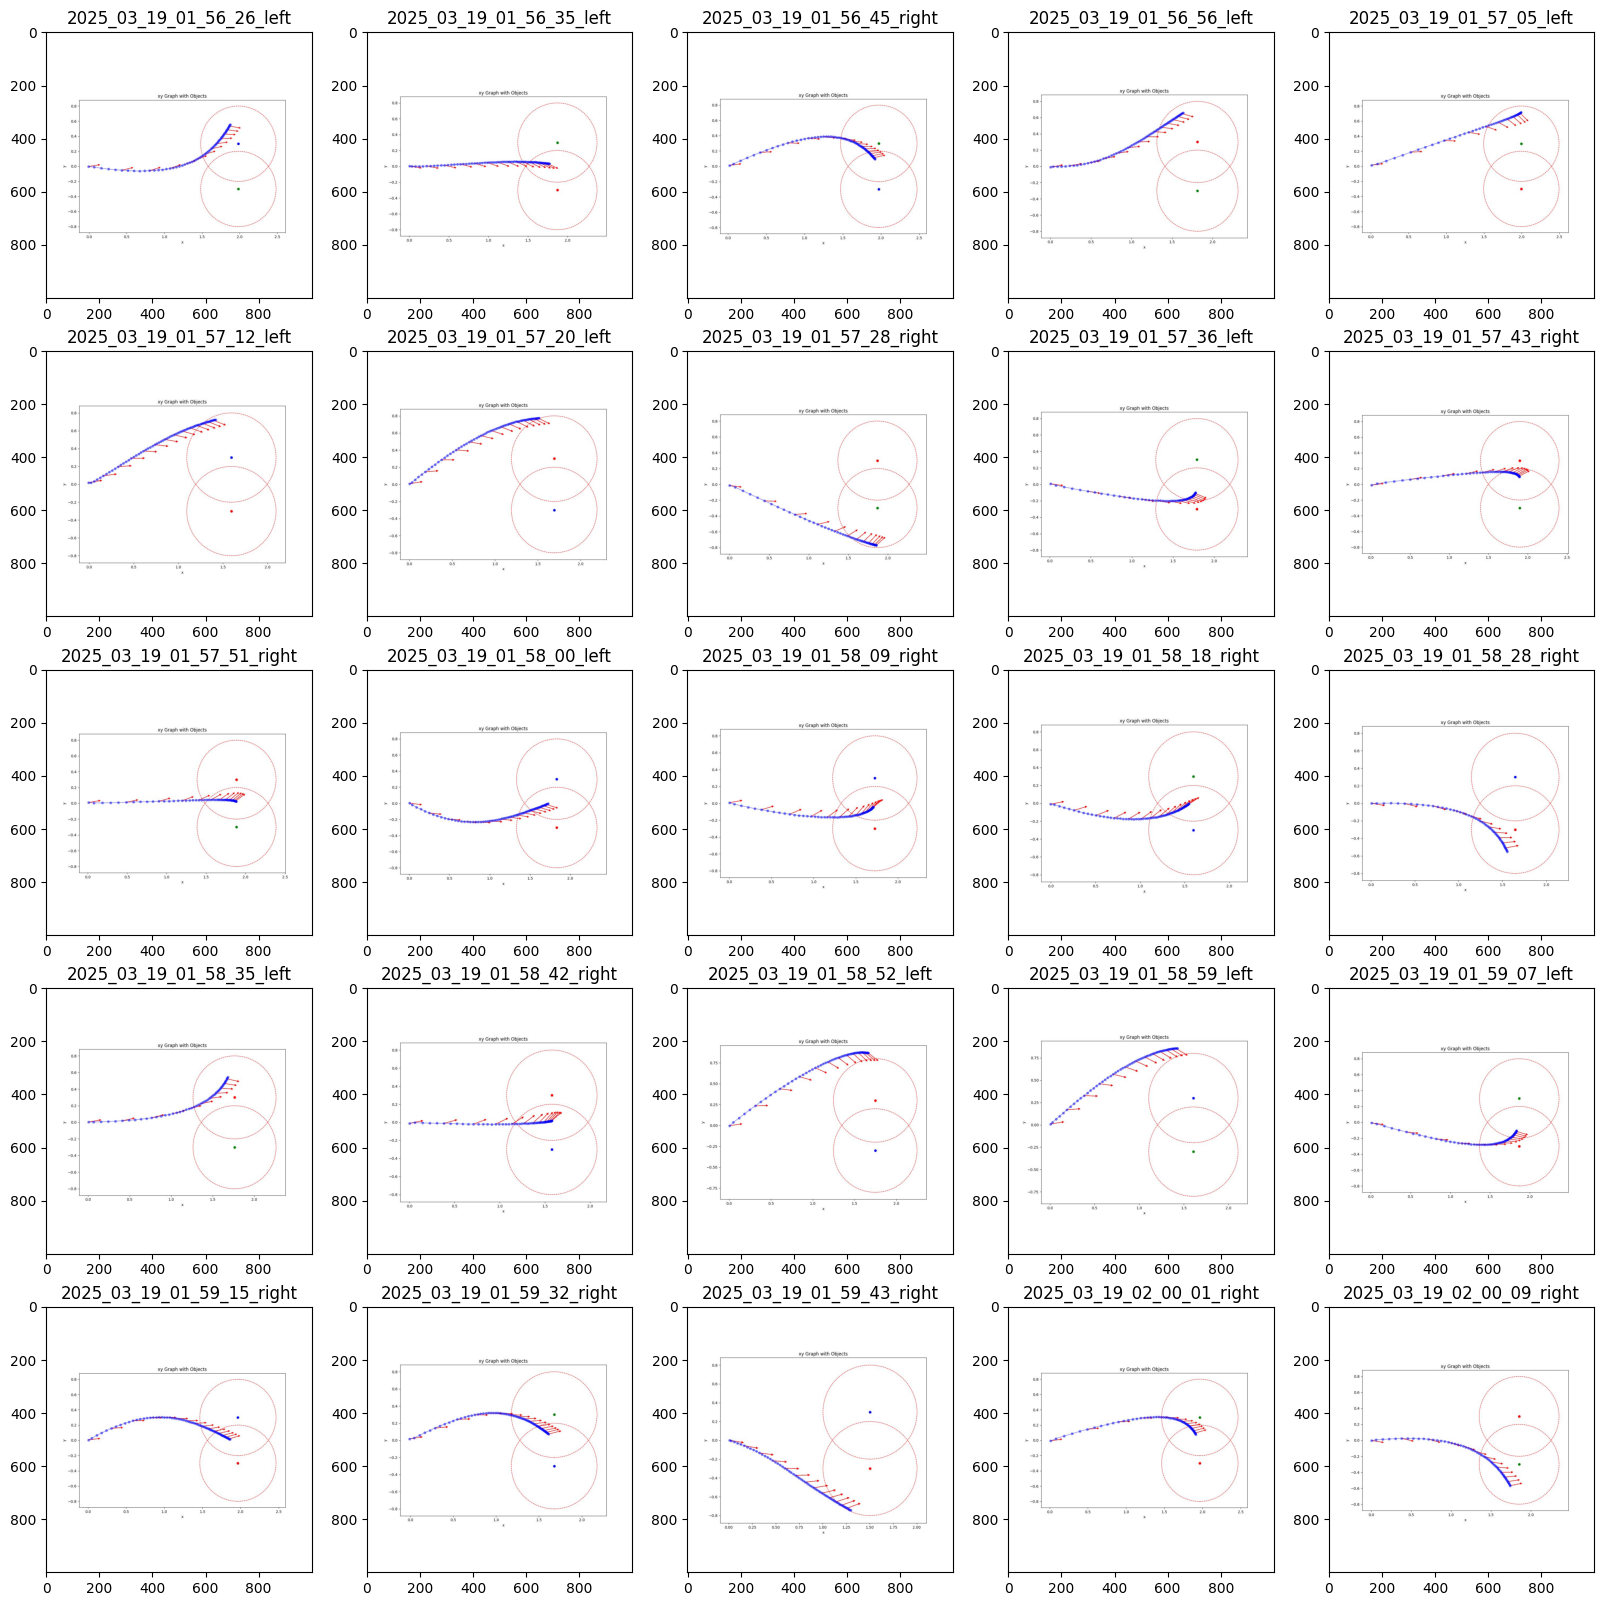

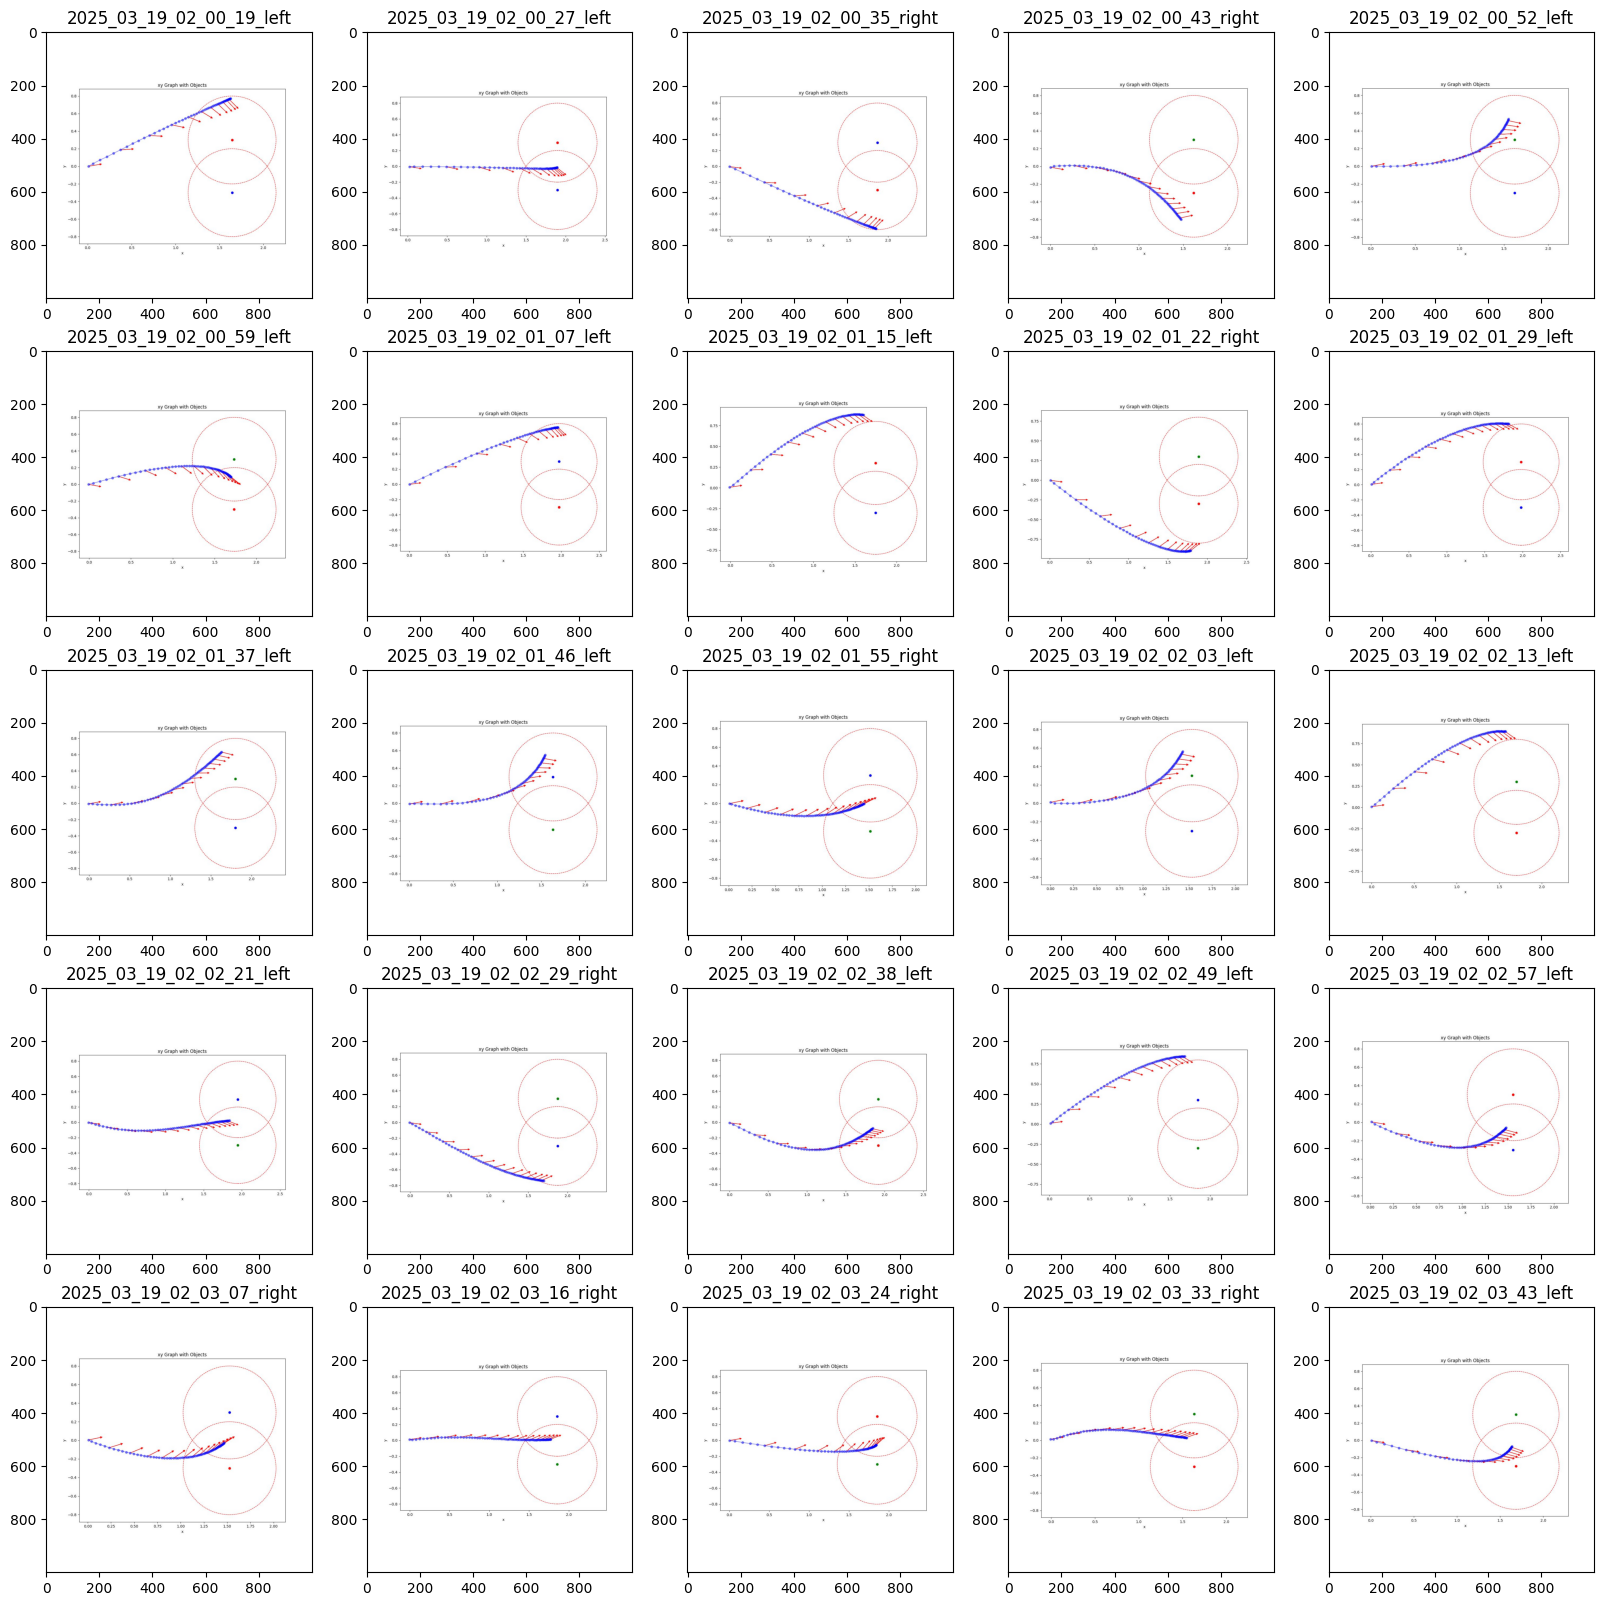

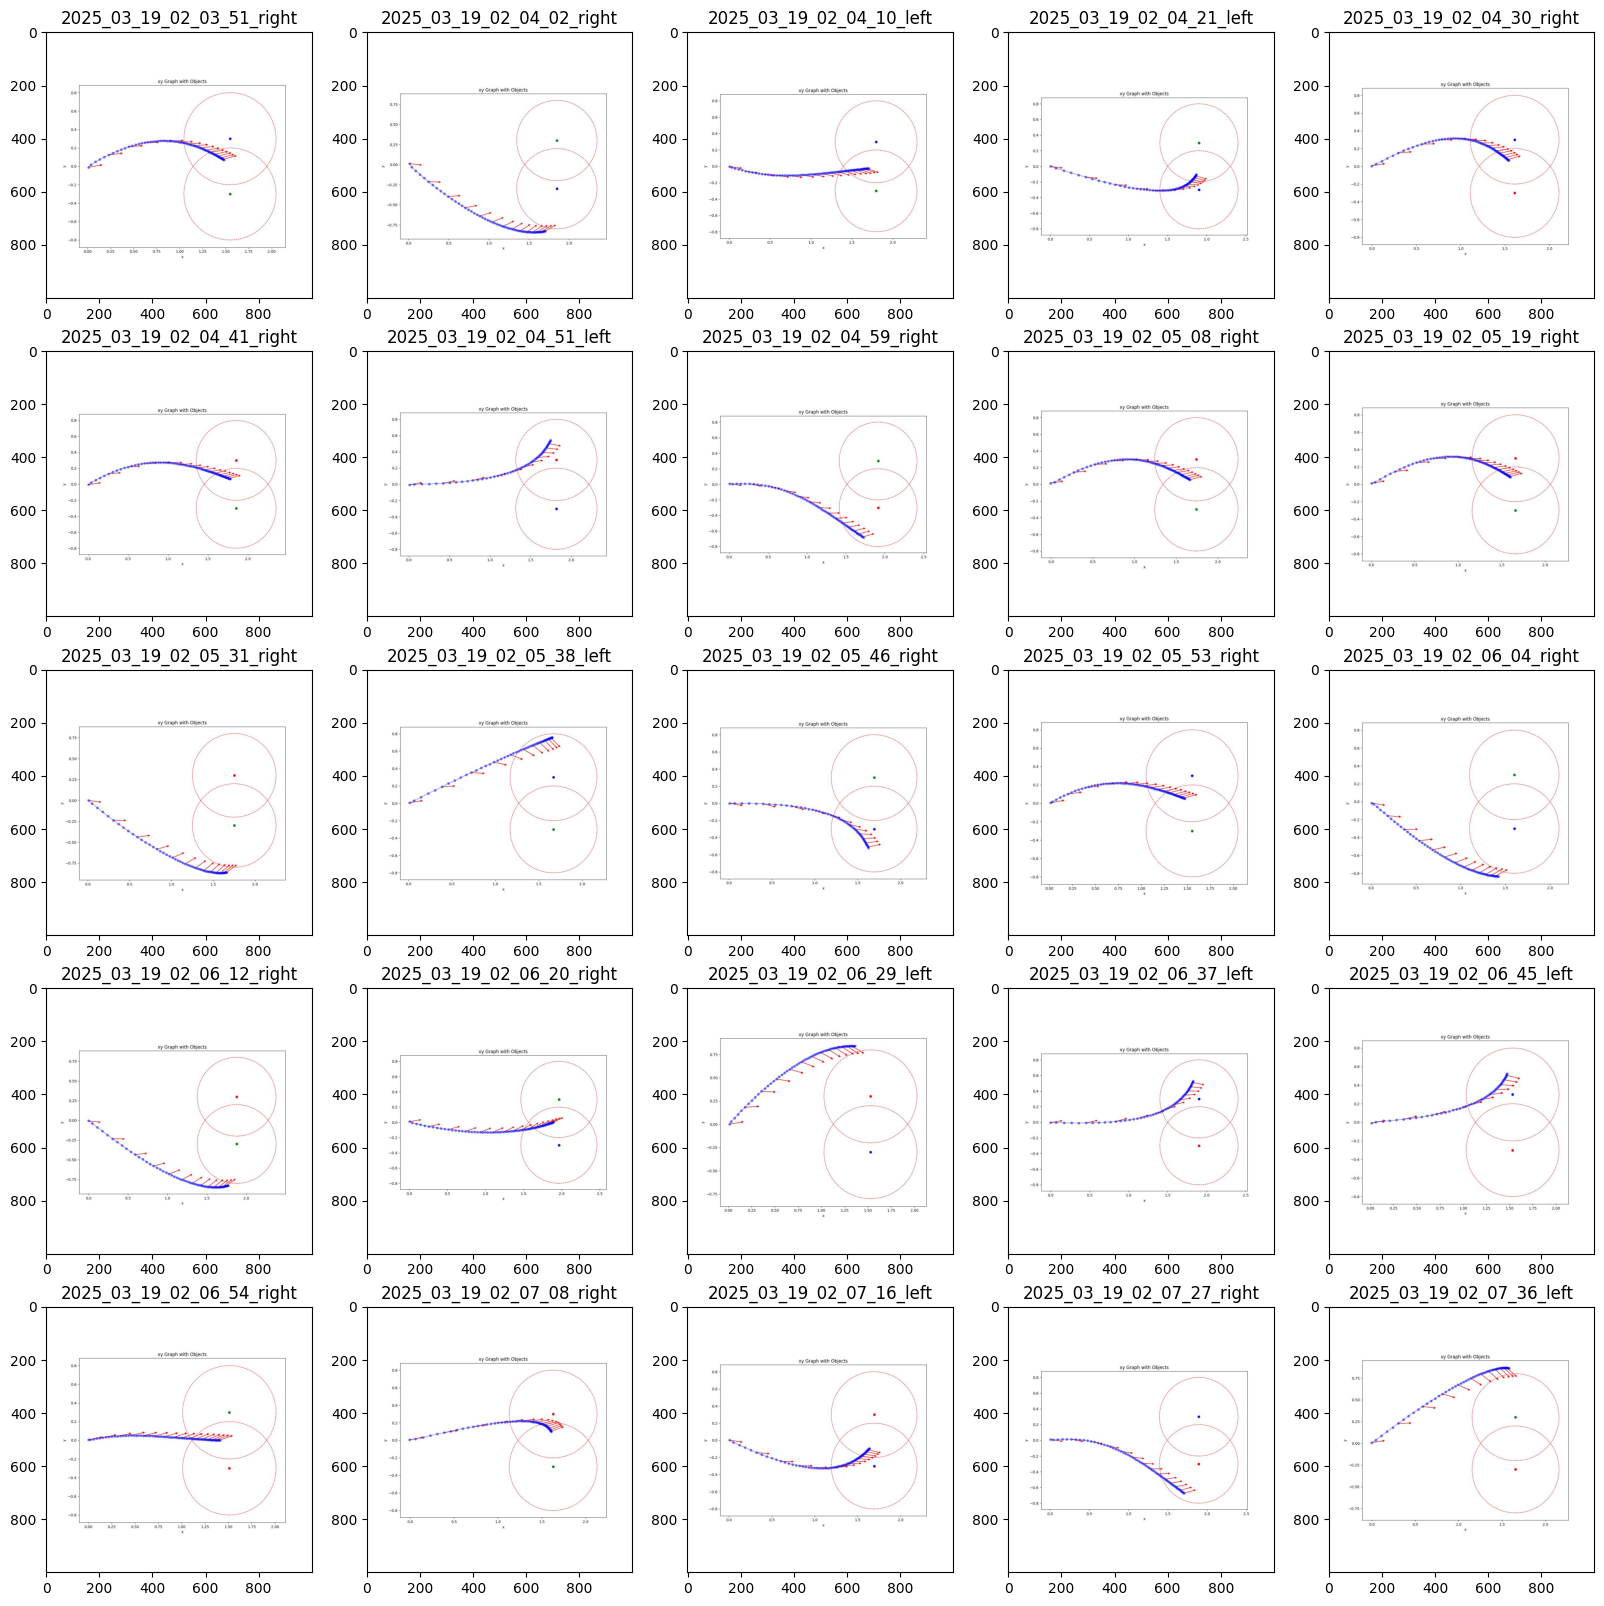

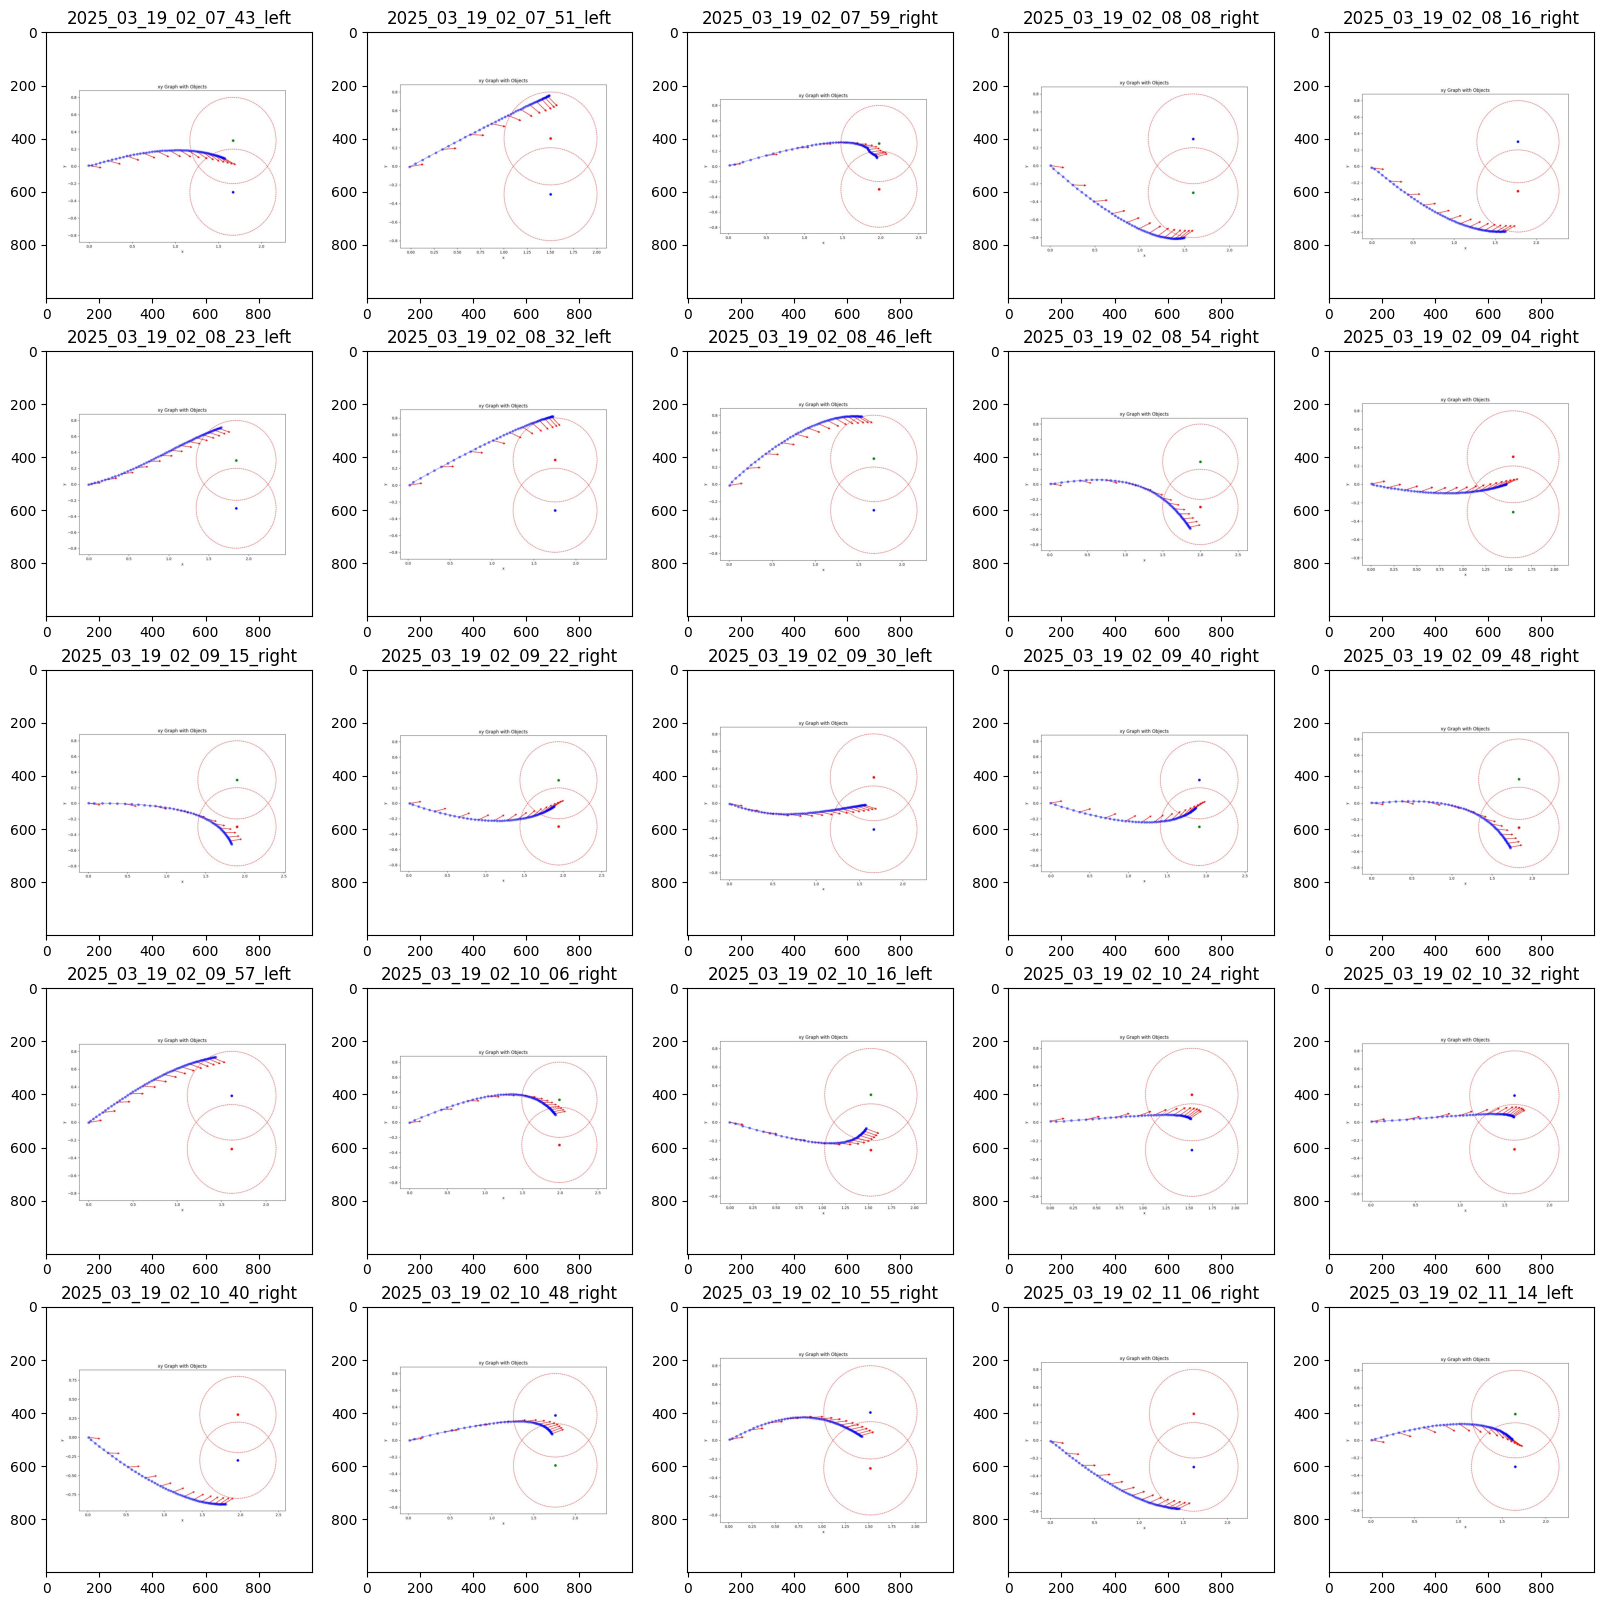

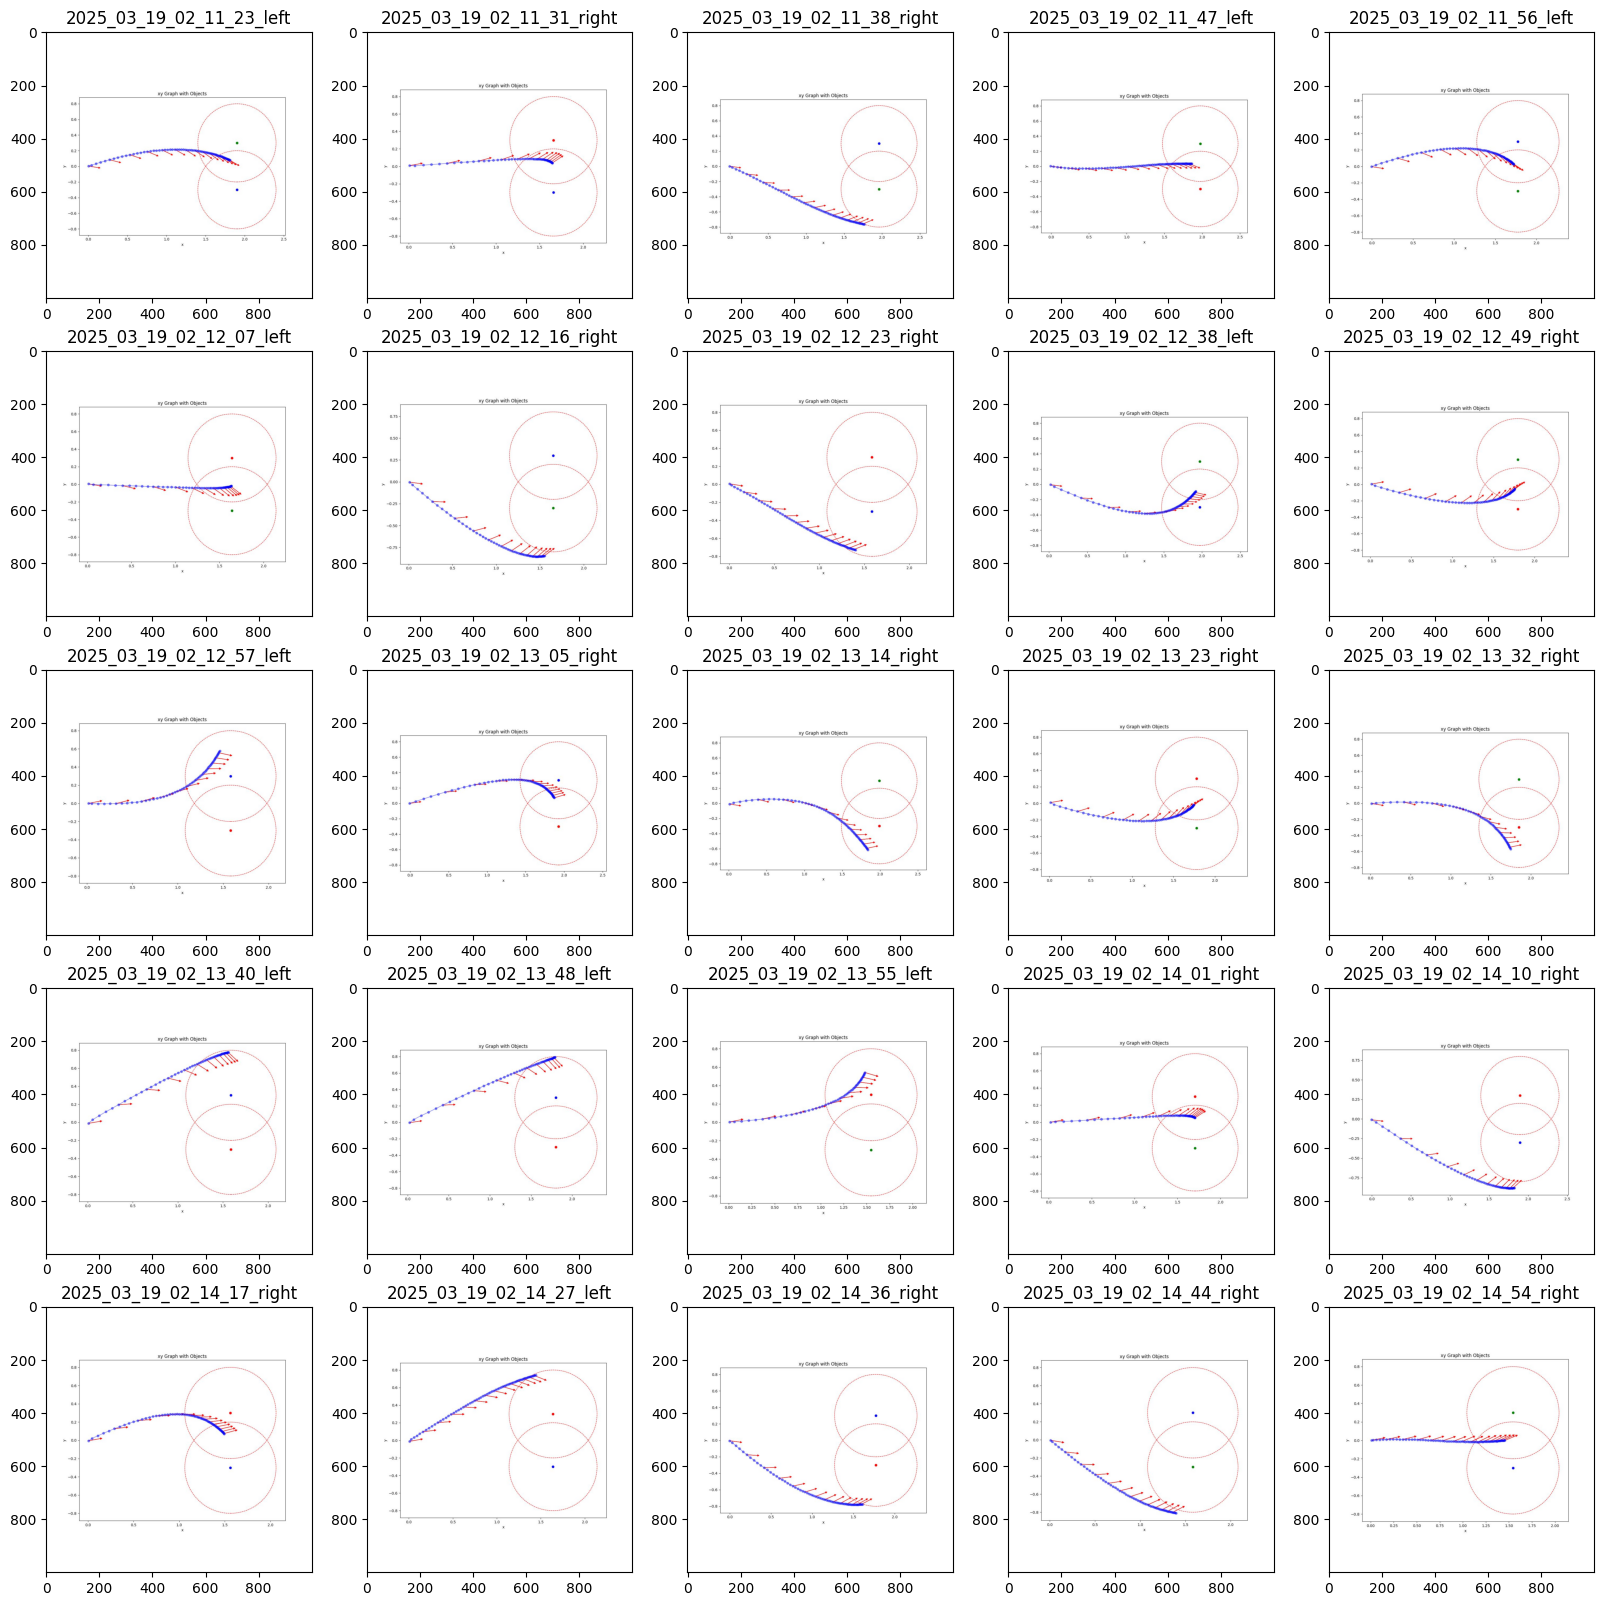

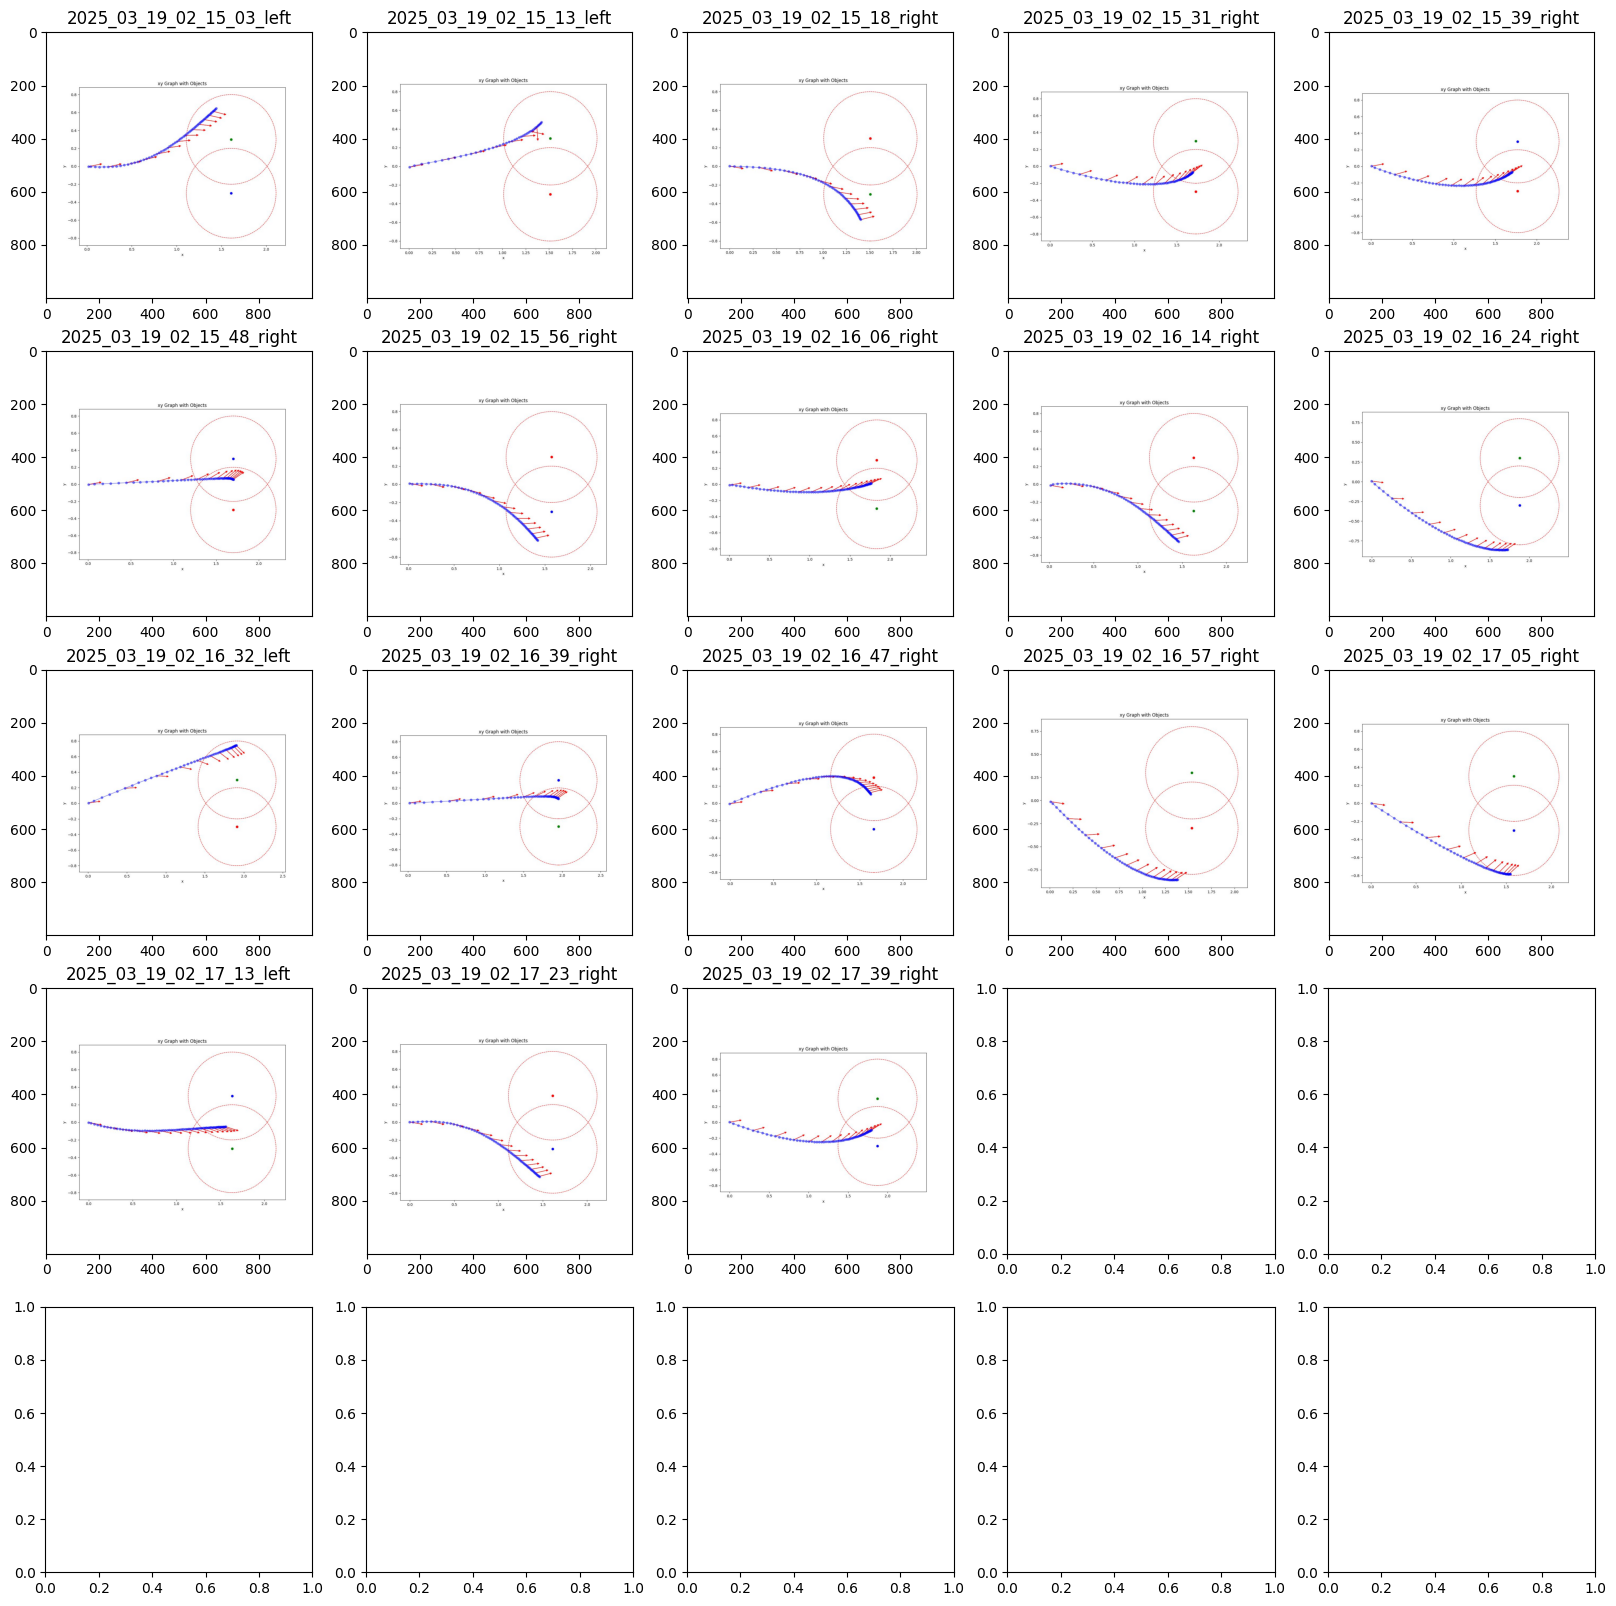

In [ ]:
plots_folders = sorted([f for f in os.listdir(plots_base) if f.startswith('2025')])
for i in range(0, len(plots_folders), 25):
    fig, axes = plt.subplots(5, 5, figsize=(20, 20))
    for j in range(5):
        for k in range(5):
            if i+j*5+k >= len(plots_folders):
                break
            run = plots_folders[i+j*5+k]
            splots = [sp for sp in os.listdir(os.path.join(plots_base, run)) if sp.startswith('sim_vel')]
            im_path = os.path.join(plots_base, run, splots[0])
            axes[j, k].imshow(plt.imread(im_path))
            axes[j, k].set_title(run)
    # plt.savefig(os.path.join(plots_base, f'plots{i}.png'))
    plt.show()
    # bdbsx = input("Press Enter to continue...")
    # if bdbsx == 'q':
    #     break
    # elif bdbsx == 'c':
    #     print("Continuing...")
    # else:
    #     bad_data_by_sim_xy[i] = bdbsx
    #     print("Bad data by sim xy:", bad_data_by_sim_xy)


In [ ]:
import cv2
import IPython.display as display
from PIL import Image
import io

cap = cv2.VideoCapture('/home/alex/flex/MCMD_Sim/results/2025_03_17_12_27_38/out_video_12_27_38.mp4')

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    _, buffer = cv2.imencode('.jpeg', frame)
    display.display(Image.open(io.BytesIO(buffer)))
    display.clear_output(wait=True)

cap.release()

In [35]:
import cv2
import time

def play_video(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Error: Could not open video.")
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_number = 0
    speed = 1.0  # Default speed (1x)
    paused = False
    repeat = True  # Enable repeat mode

    while True:
        if not paused:
            ret, frame = cap.read()
            if not ret:
                if repeat:
                    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
                    frame_number = 0
                    continue
                else:
                    break  # Exit when video ends

            # Display the frame number
            cv2.putText(frame, f'Frame: {frame_number}/{total_frames}', (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

            # cv2.imshow('Video Player', frame)
            _, buffer = cv2.imencode('.jpeg', frame)
            display.display(Image.open(io.BytesIO(buffer)))
            display.clear_output(wait=True)
            time.sleep(1 / speed)
            frame_number += 1

        # Keyboard Controls
        # key = cv2.waitKey(int(50 / speed)) & 0xFF
        # if key == ord('q'):  # Quit
        #     break
        # elif key == ord('p'):  # Pause/Resume
        #     paused = not paused
        # elif key == ord('r'):  # Restart Video
        #     cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        #     frame_number = 0
        # elif key == ord('+'):  # Increase Speed
        #     speed = min(3.0, speed + 0.1)
        # elif key == ord('-'):  # Decrease Speed
        #     speed = max(0.1, speed - 0.1)

    cap.release()
    # cv2.destroyAllWindows()


In [36]:
video_path = '/home/alex/flex/MCMD_Sim/results/2025_03_17_12_27_38/out_video_12_27_38.mp4'  # Replace with your video path
play_video(video_path)

KeyboardInterrupt: 

In [8]:
import torch
import numpy as np
import time

In [6]:
tt = torch.randn(1, 768, 8, 8)

In [9]:
# File paths for saving
torch_file = 'tensor_torch.pt'
torch_file_compressed = 'tensor_torch_compressed.pt'
numpy_file = 'tensor_numpy.npy'
numpy_file_compressed = 'tensor_numpy_compressed.npz'

# Save the tensor using PyTorch
torch.save(tt, torch_file)
torch.save(tt, torch_file_compressed, _use_new_zipfile_serialization=True)

# Save the tensor using NumPy
np.save(numpy_file, tt.numpy())
np.savez_compressed(numpy_file_compressed, data=tt.numpy())

# Loading function with timing
def load_with_time(load_func, path):
    start = time.time()
    data = load_func(path)
    end = time.time()
    return data, end - start

# Load and measure time
torch_data, torch_time = load_with_time(torch.load, torch_file)
torch_compressed_data, torch_compressed_time = load_with_time(torch.load, torch_file_compressed)

numpy_data, numpy_time = load_with_time(lambda p: torch.from_numpy(np.load(p)), numpy_file)
numpy_compressed_data, numpy_compressed_time = load_with_time(lambda p: torch.from_numpy(np.load(p)['data']), numpy_file_compressed)

# Comparison
def compare_tensors(t1, t2):
    return torch.allclose(torch.tensor(t1), torch.tensor(t2), atol=1e-6)

print(f"Torch (Uncompressed) Load Time: {torch_time:.4f} sec")
print(f"Torch (Compressed) Load Time: {torch_compressed_time:.4f} sec")
print(f"NumPy (Uncompressed) Load Time: {numpy_time:.4f} sec")
print(f"NumPy (Compressed) Load Time: {numpy_compressed_time:.4f} sec")

print("\nData Integrity Check:")
print(f"Torch (Uncompressed) == Original: {compare_tensors(tt, torch_data)}")
print(f"Torch (Compressed) == Original: {compare_tensors(tt, torch_compressed_data)}")
print(f"NumPy (Uncompressed) == Original: {compare_tensors(tt, numpy_data)}")
print(f"NumPy (Compressed) == Original: {compare_tensors(tt, numpy_compressed_data)}")


Torch (Uncompressed) Load Time: 0.0006 sec
Torch (Compressed) Load Time: 0.0003 sec
NumPy (Uncompressed) Load Time: 0.0005 sec
NumPy (Compressed) Load Time: 0.0017 sec

Data Integrity Check:
Torch (Uncompressed) == Original: True
Torch (Compressed) == Original: True
NumPy (Uncompressed) == Original: True
NumPy (Compressed) == Original: True


/tmp/ipykernel_1227577/587070343.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = load_func(path)
/tmp/ipykernel_1227577/587070343.py:31: UserWarning: To copy con

In [48]:
start = time.time()
tt2 = torch.load('/home/alex/flex/BLIP2_Features/train/save-flight-02.13.2024_21.38.25.755537/000000a.pth', weights_only=False)
print(time.time() - start)

0.011973857879638672


In [49]:
tt2.device

device(type='cuda', index=0)

In [50]:
tt2.dtype

torch.float32

In [51]:
torch.save(tt2, 'tt2.pt')

In [52]:
torch.save(tt2.cpu(), 'tt2.pt')

In [53]:
start = time.time()
tt3 = torch.load('tt2.pt', weights_only=False, map_location='cpu')
print(time.time() - start)

0.0014536380767822266


In [54]:
(tt3.to(tt2.device) - tt2).sum()

tensor(0., device='cuda:0')

In [55]:
import os
from tqdm import tqdm

In [56]:
base_dir = '/home/alex/flex/BLIP2_Features'
new_dir = '/home/alex/flex/BLIP2_Features2'


In [57]:
l1_dir = os.listdir(base_dir)
for l1 in l1_dir:
    l2_dir = os.listdir(os.path.join(base_dir, l1))
    for l2 in tqdm(l2_dir, desc=l1):
        all_files = [f for f in os.listdir(os.path.join(base_dir, l1, l2)) if f.endswith('.pth')]
        os.makedirs(os.path.join(new_dir, l1, l2), exist_ok=True)
        for f in tqdm(all_files, desc=l2, leave=False):
            tt = torch.load(os.path.join(base_dir, l1, l2, f), weights_only=False)
            torch.save(tt.cpu(), os.path.join(new_dir, l1, l2, f.replace('.pth', '.pt')))

train: 100%|██████████| 270/270 [02:51<00:00,  1.57it/s]
